In [1]:
### Import libraries ###
import copy
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
    from google.colab import drive, files

    drive.mount("/content/drive")
    folder_path = "/content/drive/MyDrive/my_data_folder/"
except ImportError:
    folder_path = "./processed_data"

In [3]:
TUNING_DIR = "nn_output/tuning"
os.makedirs(TUNING_DIR, exist_ok=True)

X_train_path = os.path.join(folder_path, "X_train.csv")
X_test_path = os.path.join(folder_path, "X_test.csv")
X_val_path = os.path.join(folder_path, "X_val.csv")
y_train_path = os.path.join(folder_path, "y_train.csv")
y_test_path = os.path.join(folder_path, "y_test.csv")
y_val_path = os.path.join(folder_path, "y_val.csv")

E1_train_path = os.path.join(folder_path, "E1_train.npy")
E2_train_path = os.path.join(folder_path, "E2_train.npy")
E1_test_path = os.path.join(folder_path, "E1_test.npy")
E2_test_path = os.path.join(folder_path, "E2_test.npy")
E1_val_path = os.path.join(folder_path, "E1_val.npy")
E2_val_path = os.path.join(folder_path, "E2_val.npy")

print(f"Data paths set. Checking if files exist...")
all_file_paths = [
    X_train_path,
    X_test_path,
    X_val_path,
    y_train_path,
    y_test_path,
    y_val_path,
    E1_train_path,
    E2_train_path,
    E1_test_path,
    E2_test_path,
    E1_val_path,
    E2_val_path,
]
for f in all_file_paths:
    print(f"{f}: {'Found' if os.path.exists(f) else 'Not Found'}")

Data paths set. Checking if files exist...
./processed_data\X_train.csv: Found
./processed_data\X_test.csv: Found
./processed_data\X_val.csv: Found
./processed_data\y_train.csv: Found
./processed_data\y_test.csv: Found
./processed_data\y_val.csv: Found
./processed_data\E1_train.npy: Found
./processed_data\E2_train.npy: Found
./processed_data\E1_test.npy: Found
./processed_data\E2_test.npy: Found
./processed_data\E1_val.npy: Found
./processed_data\E2_val.npy: Found


In [4]:
SEED = 101
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
g = torch.Generator()
g.manual_seed(101)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
TARGET_VARIABLE = "Mole fraction"

In [5]:
# X_train = pd.read_csv("X_train.csv")
# X_test = pd.read_csv("X_test.csv")
# X_val = pd.read_csv("X_val.csv")
# y_train = pd.read_csv("y_train.csv")
# y_test = pd.read_csv("y_test.csv")
# y_val = pd.read_csv("y_val.csv")

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)
X_val = pd.read_csv(X_val_path)
y_train = pd.read_csv(y_train_path)
y_test = pd.read_csv(y_test_path)
y_val = pd.read_csv(y_val_path)

In [6]:
X_train.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)
X_test.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)
X_val.drop(
    columns=["Component 1", "Component 2", "Smiles 1", "Smiles 2", "mol1", "mol2"],
    inplace=True,
)

In [7]:
def separate_features(X):
    return (
        X.iloc[:, 0:3],
        X.iloc[:, 3:203],
        X.iloc[:, 203:403],
        X.iloc[:, 403:428],
        X.iloc[:, 428:],
    )


# property_T_P, Component 1 Descriptors, Component 2 Descriptors, Property category, phase

In [8]:
(
    X_train_prop,
    X_train_comp1_desc,
    X_train_comp2_desc,
    X_train_prop_cat,
    X_train_phase,
) = separate_features(X_train)
X_test_prop, X_test_comp1_desc, X_test_comp2_desc, X_test_prop_cat, X_test_phase = (
    separate_features(X_test)
)
X_val_prop, X_val_comp1_desc, X_val_comp2_desc, X_val_prop_cat, X_val_phase = (
    separate_features(X_val)
)

In [9]:
def make_symmetric(comp1, comp2):
    X1 = np.array(comp1)
    X2 = np.array(comp2)
    prod = pd.DataFrame(X1 * X2, columns=[f"prod_{i}" for i in range(X1.shape[1])])
    summ = pd.DataFrame(X1 + X2, columns=[f"sum_{i}" for i in range(X1.shape[1])])
    return pd.concat([prod, summ], axis=1)


X_train_symmetric = make_symmetric(X_train_comp1_desc, X_train_comp2_desc)
X_val_symmetric = make_symmetric(X_val_comp1_desc, X_val_comp2_desc)
X_test_symmetric = make_symmetric(X_test_comp1_desc, X_test_comp2_desc)

# Reconstruct full feature matrix


def reconstruct(prop, symmetric, prop_cat, phase):
    dfs = [prop, symmetric, prop_cat, phase]
    for df in dfs:
        df.reset_index(drop=True, inplace=True)
    return pd.concat(dfs, axis=1)


X_train = reconstruct(X_train_prop, X_train_symmetric, X_train_prop_cat, X_train_phase)
X_val = reconstruct(X_val_prop, X_val_symmetric, X_val_prop_cat, X_val_phase)
X_test = reconstruct(X_test_prop, X_test_symmetric, X_test_prop_cat, X_test_phase)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)


def to_loader(X, y, batch_size=1024, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32).squeeze().unsqueeze(1),
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=g if shuffle else None,
        worker_init_fn=lambda worker_id: (
            np.random.seed(101 + worker_id) if shuffle else None
        ),
    )


train_loader = to_loader(X_train_scaled, y_train, shuffle=True)
val_loader = to_loader(X_val_scaled, y_val)

In [12]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
            nn.Hardtanh(min_val=0.0, max_val=1.0),
        )

    def forward(self, x):
        return self.net(x)

In [13]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])

    model = MLPRegressor(X_train.shape[1], dropout=dropout, hidden_dim=hidden_dim).to(
        device
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    fast_train_loader = to_loader(
        X_train_scaled, y_train, batch_size=2048, shuffle=True
    )
    fast_val_loader = to_loader(X_val_scaled, y_val, batch_size=2048)

    for epoch in range(50):
        model.train()
        for X_batch, y_batch in fast_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            criterion(model(X_batch), y_batch).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = np.mean(
                [
                    criterion(model(X_b.to(device)), y_b.to(device)).item()
                    for X_b, y_b in fast_val_loader
                ]
            )
        scheduler.step(val_loss)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss


study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5),
)
study.optimize(objective, n_trials=30, show_progress_bar=True)
print("Best params:", study.best_params)
print("Best val MSE:", study.best_value)

[I 2026-04-09 14:10:15,538] A new study created in memory with name: no-name-1f4a7387-eead-48ab-8ed4-f56beaba6232
Best trial: 0. Best value: 0.0481268:   3%|▎         | 1/30 [00:28<13:37, 28.17s/it]

[I 2026-04-09 14:10:43,713] Trial 0 finished with value: 0.048126772666970886 and parameters: {'lr': 0.00016668239059935386, 'dropout': 0.3810012643730325, 'hidden_dim': 128}. Best is trial 0 with value: 0.048126772666970886.


Best trial: 1. Best value: 0.0455109:   7%|▋         | 2/30 [00:54<12:33, 26.90s/it]

[I 2026-04-09 14:11:09,714] Trial 1 finished with value: 0.04551086388528347 and parameters: {'lr': 5.245937140356094e-05, 'dropout': 0.24391386077887203, 'hidden_dim': 512}. Best is trial 1 with value: 0.04551086388528347.


Best trial: 2. Best value: 0.0283741:  10%|█         | 3/30 [01:22<12:19, 27.38s/it]

...

[I 2026-04-09 14:17:09,024] Trial 27 pruned. 


Best trial: 26. Best value: 0.0240222:  97%|█████████▋| 29/30 [07:21<00:15, 15.78s/it]

[I 2026-04-09 14:17:36,982] Trial 28 finished with value: 0.02435551645855109 and parameters: {'lr': 0.0010665847247356209, 'dropout': 0.12347579433640789, 'hidden_dim': 256}. Best is trial 26 with value: 0.024022238329052925.


Best trial: 26. Best value: 0.0240222: 100%|██████████| 30/30 [07:24<00:00, 14.83s/it]

[I 2026-04-09 14:17:40,462] Trial 29 pruned. 
Best params: {'lr': 0.0015957325047859818, 'dropout': 0.13641607357543872, 'hidden_dim': 256}
Best val MSE: 0.024022238329052925


In [14]:
# Training loop

best_params = study.best_params
model = MLPRegressor(
    X_train.shape[1],
    hidden_dim=best_params["hidden_dim"],
    dropout=best_params["dropout"],
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
best_val_loss = float("inf")
best_model_state = None
train_loss_history = []
val_loss_history = []

n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_losses = [
            criterion(model(X_b.to(device)), y_b.to(device)).item()
            for X_b, y_b in val_loader
        ]
    val_loss = np.mean(val_losses)
    scheduler.step(np.mean(val_losses))
    # Save best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
    # Add at bottom of the epoch loop:
    train_loss_history.append(np.mean(train_losses))
    val_loss_history.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{n_epochs} — Train MSE: {np.mean(train_losses):.4f} — Val MSE: {val_loss:.4f}"
        )

Epoch 10/300 — Train MSE: 0.0433 — Val MSE: 0.0365
Epoch 20/300 — Train MSE: 0.0340 — Val MSE: 0.0356
Epoch 30/300 — Train MSE: 0.0294 — Val MSE: 0.0265
Epoch 40/300 — Train MSE: 0.0276 — Val MSE: 0.0250
Epoch 50/300 — Train MSE: 0.0277 — Val MSE: 0.0264
Epoch 60/300 — Train MSE: 0.0263 — Val MSE: 0.0235
Epoch 70/300 — Train MSE: 0.0252 — Val MSE: 0.0221
Epoch 80/300 — Train MSE: 0.0245 — Val MSE: 0.0261
Epoch 90/300 — Train MSE: 0.0241 — Val MSE: 0.0219
Epoch 100/300 — Train MSE: 0.0242 — Val MSE: 0.0227
Epoch 110/300 — Train MSE: 0.0239 — Val MSE: 0.0217
Epoch 120/300 — Train MSE: 0.0234 — Val MSE: 0.0217
Epoch 130/300 — Train MSE: 0.0235 — Val MSE: 0.0216
Epoch 140/300 — Train MSE: 0.0234 — Val MSE: 0.0209
Epoch 150/300 — Train MSE: 0.0232 — Val MSE: 0.0217
Epoch 160/300 — Train MSE: 0.0233 — Val MSE: 0.0219
Epoch 170/300 — Train MSE: 0.0235 — Val MSE: 0.0223
Epoch 180/300 — Train MSE: 0.0233 — Val MSE: 0.0208
Epoch 190/300 — Train MSE: 0.0233 — Val MSE: 0.0223
Epoch 200/300 — Train

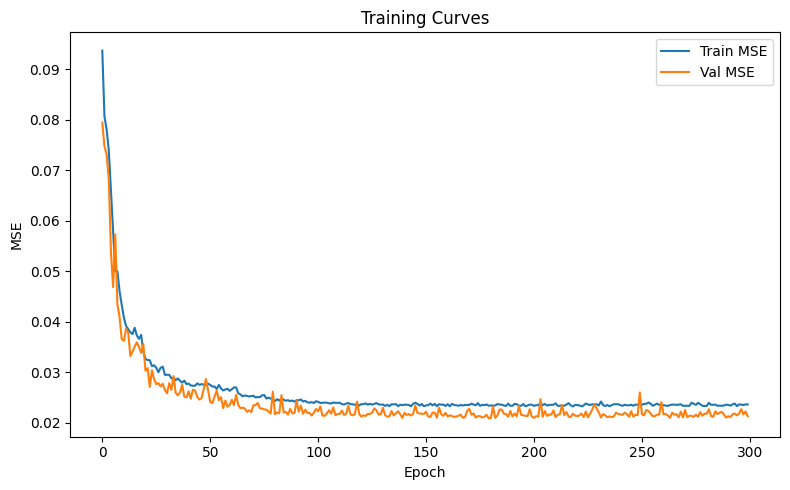

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="Train MSE")
plt.plot(val_loss_history, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Curves")
plt.legend()
plt.tight_layout()
plt.savefig("training_curves_mlp.png", dpi=150)
plt.show()

In [16]:
torch.save(
    {
        "model_state_dict": best_model_state,
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "input_dim": X_train.shape[1],
        "hidden_dim": best_params["hidden_dim"],
        "dropout": best_params["dropout"],
    },
    "mlp_baseline.pth",
)
print("Checkpoint saved to mlp_baseline.pth")

Checkpoint saved to mlp_baseline.pth


In [21]:
def evaluate_model(
    y_true,
    y_pred,
    save_dir="./nn_output_baseline",
    filename="results",
    show_plot=True,
    n_bootstrap=1000,
):
    """Evaluate MLP on test set with bootstrap 95% CI (mu +/- 1.96*std).
    Saves scatter plot, histogram, predictions, true labels, and metrics."""
    os.makedirs(save_dir, exist_ok=True)
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Point estimates
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    tau = kendalltau(y_true, y_pred).correlation

    # Bootstrap on test set
    rng = np.random.default_rng(101)
    mae_scores, mse_scores, r2_scores, tau_scores = [], [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_true), len(y_true))
        mae_scores.append(mean_absolute_error(y_true[idx], y_pred[idx]))
        mse_scores.append(mean_squared_error(y_true[idx], y_pred[idx]))
        r2_scores.append(r2_score(y_true[idx], y_pred[idx]))
        tau_scores.append(kendalltau(y_true[idx], y_pred[idx]).correlation)

    def ci95(scores):
        mu = np.mean(scores)
        std = np.std(scores, ddof=1)
        return mu, std, mu - 1.96 * std, mu + 1.96 * std

    mae_mu, mae_std, mae_lo, mae_hi = ci95(mae_scores)
    mse_mu, mse_std, mse_lo, mse_hi = ci95(mse_scores)
    r2_mu, r2_std, r2_lo, r2_hi = ci95(r2_scores)
    tau_mu, tau_std, tau_lo, tau_hi = ci95(tau_scores)

    print(
        f"MAE         = {mae:.4f}  |  bootstrap mu={mae_mu:.4f}, std={mae_std:.4f}  (95% CI: {mae_lo:.4f} – {mae_hi:.4f})"
    )
    print(
        f"MSE         = {mse:.4f}  |  bootstrap mu={mse_mu:.4f}, std={mse_std:.4f}  (95% CI: {mse_lo:.4f} – {mse_hi:.4f})"
    )
    print(
        f"R²          = {r2:.4f}  |  bootstrap mu={r2_mu:.4f}, std={r2_std:.4f}  (95% CI: {r2_lo:.4f} – {r2_hi:.4f})"
    )
    print(
        f"Kendall’s τ  = {tau:.4f}  |  bootstrap mu={tau_mu:.4f}, std={tau_std:.4f}  (95% CI: {tau_lo:.4f} – {tau_hi:.4f})"
    )

    results = {
        "MAE": {
            "value": mae,
            "bootstrap_mu": mae_mu,
            "bootstrap_std": mae_std,
            "ci95_lo": mae_lo,
            "ci95_hi": mae_hi,
        },
        "MSE": {
            "value": mse,
            "bootstrap_mu": mse_mu,
            "bootstrap_std": mse_std,
            "ci95_lo": mse_lo,
            "ci95_hi": mse_hi,
        },
        "R2": {
            "value": r2,
            "bootstrap_mu": r2_mu,
            "bootstrap_std": r2_std,
            "ci95_lo": r2_lo,
            "ci95_hi": r2_hi,
        },
        "Kendall_tau": {
            "value": tau,
            "bootstrap_mu": tau_mu,
            "bootstrap_std": tau_std,
            "ci95_lo": tau_lo,
            "ci95_hi": tau_hi,
        },
    }

    # Save metrics
    metrics_path = os.path.join(save_dir, f"{filename}_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Metrics saved to {metrics_path}")

    # Save predictions and true labels
    preds_path = os.path.join(save_dir, f"{filename}_predictions.json")
    with open(preds_path, "w") as f:
        json.dump({"y_true": y_true.tolist(), "y_pred": y_pred.tolist()}, f)
    print(f"Predictions saved to {preds_path}")

    if show_plot:
        # Actual vs Predicted scatter
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(y_true, y_pred, alpha=0.1, s=10)
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, "r--", label="Perfect fit")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title("Actual vs Predicted")
        ax.legend()
        scatter_path = os.path.join(save_dir, f"{filename}_actual_vs_predicted.png")
        fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Scatter plot saved to {scatter_path}")

        # Distribution histogram: True vs Predicted
        fig, ax = plt.subplots(figsize=(7, 5))
        bins = np.linspace(
            min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max()), 50
        )
        ax.hist(
            y_true,
            bins=bins,
            alpha=0.6,
            label="True",
            color="steelblue",
            edgecolor="none",
        )
        ax.hist(
            y_pred,
            bins=bins,
            alpha=0.6,
            label="Predicted",
            color="darkorange",
            edgecolor="none",
        )
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.set_title("Distribution: True vs Predicted")
        ax.legend()
        hist_path = os.path.join(save_dir, f"{filename}_distribution_histogram.png")
        fig.savefig(hist_path, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Histogram saved to {hist_path}")

    return results

In [22]:
# Load model from checkpoint
checkpoint = torch.load("mlp_baseline.pth", map_location=device, weights_only=False)
model = MLPRegressor(
    input_dim=checkpoint["input_dim"],
    hidden_dim=checkpoint["hidden_dim"],
    dropout=checkpoint["dropout"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(
    f"Loaded MLP | input_dim={checkpoint['input_dim']}, "
    f"hidden_dim={checkpoint['hidden_dim']}, dropout={checkpoint['dropout']:.2f}, "
    f"best_val_loss={checkpoint['best_val_loss']:.4f}"
)

Loaded MLP | input_dim=430, hidden_dim=256, dropout=0.14, best_val_loss=0.0208


=== Test Set ===
MAE         = 0.0817  |  bootstrap mu=0.0817, std=0.0011  (95% CI: 0.0795 – 0.0838)
MSE         = 0.0200  |  bootstrap mu=0.0200, std=0.0005  (95% CI: 0.0191 – 0.0209)
R²          = 0.7902  |  bootstrap mu=0.7902, std=0.0048  (95% CI: 0.7809 – 0.7995)
Kendall’s τ  = 0.7362  |  bootstrap mu=0.7363, std=0.0038  (95% CI: 0.7289 – 0.7437)
Metrics saved to ./nn_output_baseline\test_metrics.json
Predictions saved to ./nn_output_baseline\test_predictions.json


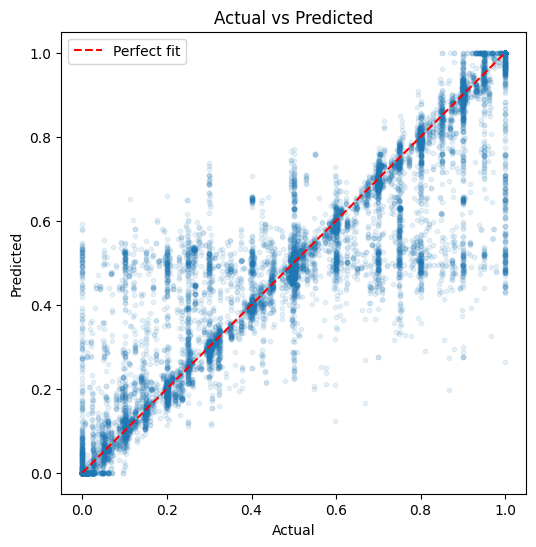

Scatter plot saved to ./nn_output_baseline\test_actual_vs_predicted.png


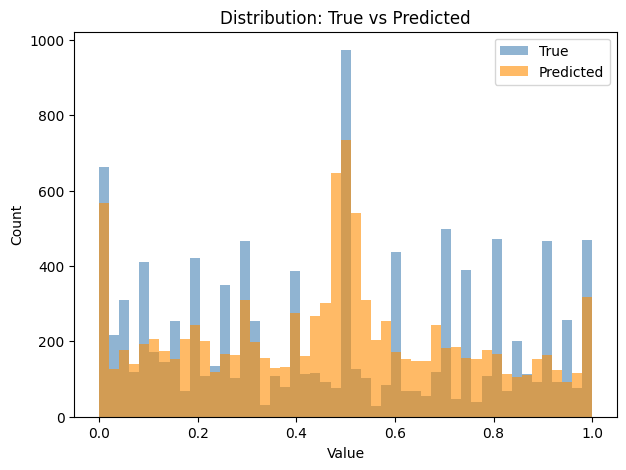

Histogram saved to ./nn_output_baseline\test_distribution_histogram.png


In [23]:
# Run inference on test set
with torch.no_grad():
    y_pred_test = (
        model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device))
        .cpu()
        .numpy()
        .flatten()
    )

print("=== Test Set ===")
results_test = evaluate_model(
    y_test,
    y_pred_test,
    save_dir="./nn_output_baseline",
    filename="test",
    show_plot=True,
)